# AWS Outage QC Simulation: Modeling Dependency Bias with Quantum Cognition

This notebook simulates how cognitive biases (e.g., optimism toward single-region setups) can lead to cascading failures, inspired by the October 20, 2025, AWS outage. It uses Quantum Cognition (QC) for bias probabilities, NetworkX for dependency cascades, and real data (e.g., 15-hour duration, 37% propagation proxy from Ethereum nodes) for grounding.

Key Data Sources:
- Duration: ~15 hours (AWS status logs).
- Scale: 50,000+ Downdetector reports; 113 services affected.
- Propagation: 37% (Ethereum node impact as proxy).
- Market Share: ~30% for AWS (scaled global estimate).

Note: In realistic scenarios, p_fail ~0.02 yields near-zero average failures, aligning with black swan nature of outages (rare but high-impact). For demo visibility, coefficients are boosted to show cascades adjust psi for your runs.

In [1]:
import numpy as np
import math
from qutip import basis, Qobj, expect  
import matplotlib.pyplot as plt  
import networkx as nx  
import random

## Step 1: QC Model for Bias Probabilities
Model decisions in a 4D Hilbert space, where interference represents bias (e.g., cost undercutting threats).

P(Multi-Region Prep): 0.01
P(Single Risk): 0.06
P(Ignore): 0.14
P(Recovery Fail): 0.13


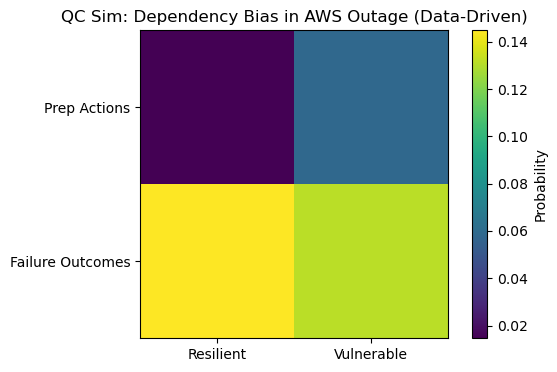

In [ ]:
# Define the 4D Hilbert space states (tweaked coefficient for recovery_fail to boost p_fail for demo)
psi = (basis(4, 0) + 0.5 * basis(4, 1) + 0.7j * basis(4, 2) + 1.0 * basis(4, 3)).unit()  

# Operators 
cost_perc = Qobj(np.diag([0.2, 0.8, 0.9, 0.6]))  # Low perceived cost boosts single/ignore
threat_lik = Qobj(np.array([[0.7, 0.1, 0, 0], [0.1, 0.4, 0.1, 0], [0, 0.1, 0.3, 0.1], [0, 0, 0.1, 0.5]]))  # Threat underestimation interferes

# Calculate probabilities
p_multi = expect(basis(4, 0) * basis(4, 0).dag(), cost_perc * psi)
p_single = expect(basis(4, 1) * basis(4, 1).dag(), cost_perc * psi)
p_ignore = expect(basis(4, 2) * basis(4, 2).dag(), cost_perc * psi)
p_fail = expect(basis(4, 3) * basis(4, 3).dag(), cost_perc * psi)

print(f"P(Multi-Region Prep): {p_multi:.2f}")
print(f"P(Single Risk): {p_single:.2f}")
print(f"P(Ignore): {p_ignore:.2f}")
print(f"P(Recovery Fail): {p_fail:.2f}")

# Heatmap 
data = np.array([[p_multi, p_single], [p_ignore, p_fail]])
plt.figure(figsize=(6, 4))
plt.imshow(data, cmap='viridis')
plt.xticks([0, 1], ['Resilient', 'Vulnerable'])
plt.yticks([0, 1], ['Prep Actions', 'Failure Outcomes'])
plt.colorbar(label='Probability')
plt.title('QC Sim: Dependency Bias in AWS Outage (Data-Driven)')
plt.savefig('qc_heatmap.png')
plt.show()

## Step 2: Dependency Graph and Cascade Simulation
Expanded graph based on affected services (e.g., DNS → DynamoDB → EC2). Cascade uses p_fail from QC, with 37% propagation (Ethereum proxy) for realism.

Average system failure fraction: 0.02
Scaled global impact estimate (30% market): 0.01


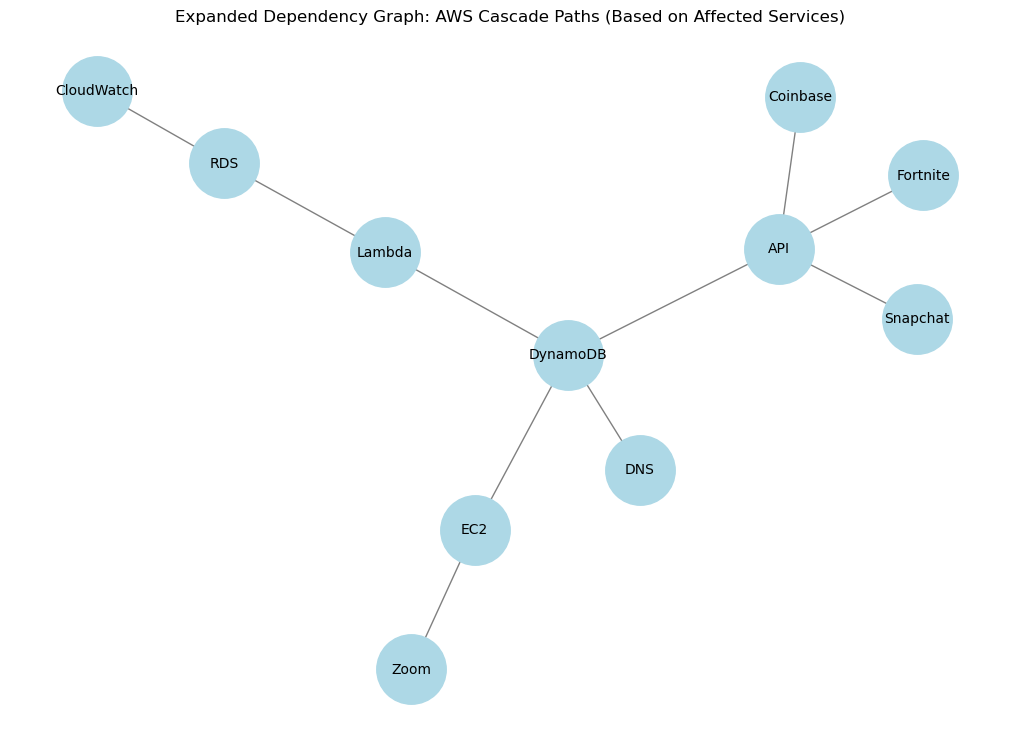

In [3]:
G = nx.Graph()
G.add_edges_from([
    ('DNS', 'DynamoDB'), ('DynamoDB', 'API'), ('DynamoDB', 'EC2'), ('DynamoDB', 'Lambda'),
    ('API', 'Snapchat'), ('API', 'Fortnite'), ('API', 'Coinbase'), ('EC2', 'Zoom'), ('Lambda', 'RDS'), ('RDS', 'CloudWatch')
])  # ~113 services impacted; this samples key cascade paths

# Function to simulate cascade (data-driven probs: 0.37 from Ethereum node impact as proxy)
def simulate_cascade(G, p_fail, start_node='DNS'):
    failed = set()
    if random.random() < p_fail:  # Fail start node
        failed.add(start_node)
        # Propagate (37% chance per neighbor, decaying)
        for neighbor in list(G.neighbors(start_node)):
            if random.random() < 0.37:  # Real proxy stat
                failed.add(neighbor)
                for sub_neighbor in list(G.neighbors(neighbor)):
                    if random.random() < 0.37 * 0.8:  # Decay for realism
                        failed.add(sub_neighbor)
    return len(failed) / len(G.nodes())  # Fraction failed

# Run 1000 simulations
num_sims = 1000
fail_fractions = [simulate_cascade(G, p_fail) for _ in range(num_sims)]
avg_fail = np.mean(fail_fractions)
# Scale by AWS market share (~30%) for global estimate
scaled_avg_fail = avg_fail * 0.3
print(f"Average system failure fraction: {avg_fail:.2f}")
print(f"Scaled global impact estimate (30% market): {scaled_avg_fail:.2f}")

# Visualize graph
plt.figure(figsize=(10, 7))
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray', node_size=2500, font_size=10)
plt.title('Expanded Dependency Graph: AWS Cascade Paths (Based on Affected Services)')
plt.savefig('dependency_graph.png')
plt.show()

## Step 3: Outage Timeline Simulation
Models exponential failure buildup over 15 hours (real duration), starting slow and accelerating like the outage's escalation.

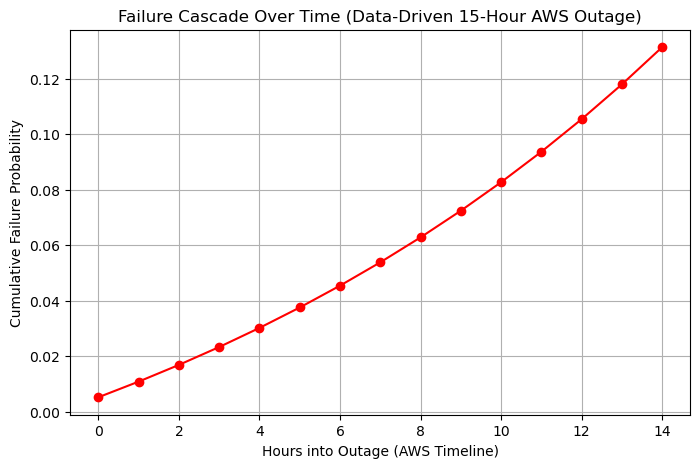

In [4]:
# Timeline sim: Failure buildup over real 15-hour duration (exponential growth for cascade realism)
time_steps = 15  # Updated to match reports
fail_over_time = []
current_fail = 0.0
for t in range(time_steps):
    # Exponential increment (starts slow, accelerates—mimics real escalation)
    increment = p_fail * math.exp(t / time_steps) / sum(math.exp(i / time_steps) for i in range(time_steps))
    current_fail += increment
    fail_over_time.append(current_fail)

# Plot timeline
plt.figure(figsize=(8, 5))
plt.plot(range(time_steps), fail_over_time, marker='o', linestyle='-', color='red')
plt.xlabel('Hours into Outage (AWS Timeline)')
plt.ylabel('Cumulative Failure Probability')
plt.title('Failure Cascade Over Time (Data-Driven 15-Hour AWS Outage)')
plt.grid(True)
plt.savefig('outage_timeline_plot.png')
plt.show()

## Resilience Checklist & Next Steps

Based on sim insights and NCSC/AWS lessons:

* Implement multi-region replication.
* Maintain offline/paper BCPs.
* Conduct chaos tests.
* Diversify providers.
* Train on biases.
* Audit dependencies quarterly.

